In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
sns.set_theme(style="whitegrid")
print("Libraries loaded!")

Libraries loaded!


In [4]:
df = pd.read_csv(r'C:\Users\thivy\loan-default-predictor\data\raw\application_train.csv')
print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
df.head()

Dataset shape: (307511, 122)
Rows: 307,511  |  Columns: 122


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,...,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-19005,-3039,-9833.0,-2437,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.028663,-19932,-3038,-4311.0,-3458,NaN,1,1,0,...,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


=== CLASS BALANCE ===
Non-Default (0): 282,686  (91.9%)
Default     (1): 24,825  (8.1%)

Imbalance ratio: 11.4x


C:\Users\thivy\AppData\Local\Temp\ipykernel_26424\520034335.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Non-Default', 'Default'], y=target_counts.values, palette=['#2ecc71','#e74c3c'])


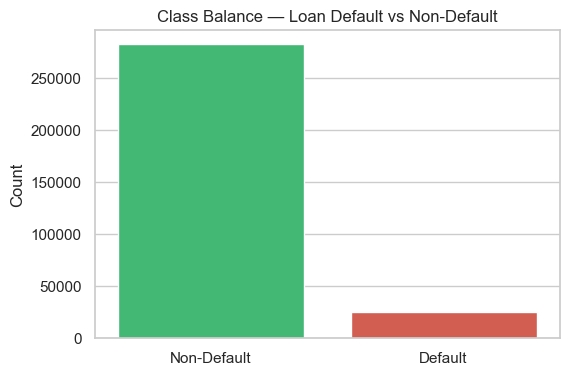

In [5]:
target_counts = df['TARGET'].value_counts()
target_pct = df['TARGET'].value_counts(normalize=True) * 100

print("=== CLASS BALANCE ===")
print(f"Non-Default (0): {target_counts[0]:,}  ({target_pct[0]:.1f}%)")
print(f"Default     (1): {target_counts[1]:,}  ({target_pct[1]:.1f}%)")
print(f"\nImbalance ratio: {target_counts[0]/target_counts[1]:.1f}x")

plt.figure(figsize=(6,4))
sns.barplot(x=['Non-Default', 'Default'], y=target_counts.values, palette=['#2ecc71','#e74c3c'])
plt.title('Class Balance — Loan Default vs Non-Default')
plt.ylabel('Count')
plt.show()

=== TOP 20 COLUMNS WITH MISSING VALUES ===
                          Missing Count  Missing %
COMMONAREA_AVG                   214865  69.872297
COMMONAREA_MODE                  214865  69.872297
COMMONAREA_MEDI                  214865  69.872297
NONLIVINGAPARTMENTS_MEDI         213514  69.432963
NONLIVINGAPARTMENTS_MODE         213514  69.432963
NONLIVINGAPARTMENTS_AVG          213514  69.432963
FONDKAPREMONT_MODE               210295  68.386172
LIVINGAPARTMENTS_AVG             210199  68.354953
LIVINGAPARTMENTS_MEDI            210199  68.354953
LIVINGAPARTMENTS_MODE            210199  68.354953
FLOORSMIN_MODE                   208642  67.848630
FLOORSMIN_AVG                    208642  67.848630
FLOORSMIN_MEDI                   208642  67.848630
YEARS_BUILD_AVG                  204488  66.497784
YEARS_BUILD_MODE                 204488  66.497784
YEARS_BUILD_MEDI                 204488  66.497784
OWN_CAR_AGE                      202929  65.990810
LANDAREA_MEDI                    182590

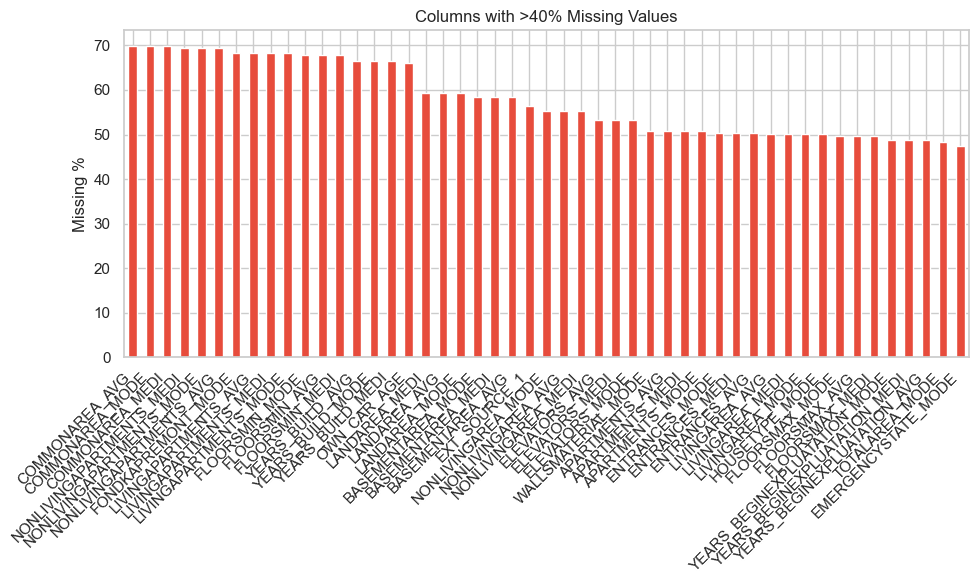

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print("=== TOP 20 COLUMNS WITH MISSING VALUES ===")
print(missing_df[missing_df['Missing %'] > 0].head(20))

plt.figure(figsize=(10,6))
missing_df[missing_df['Missing %'] > 40]['Missing %'].plot(kind='bar', color='#e74c3c')
plt.title('Columns with >40% Missing Values')
plt.ylabel('Missing %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

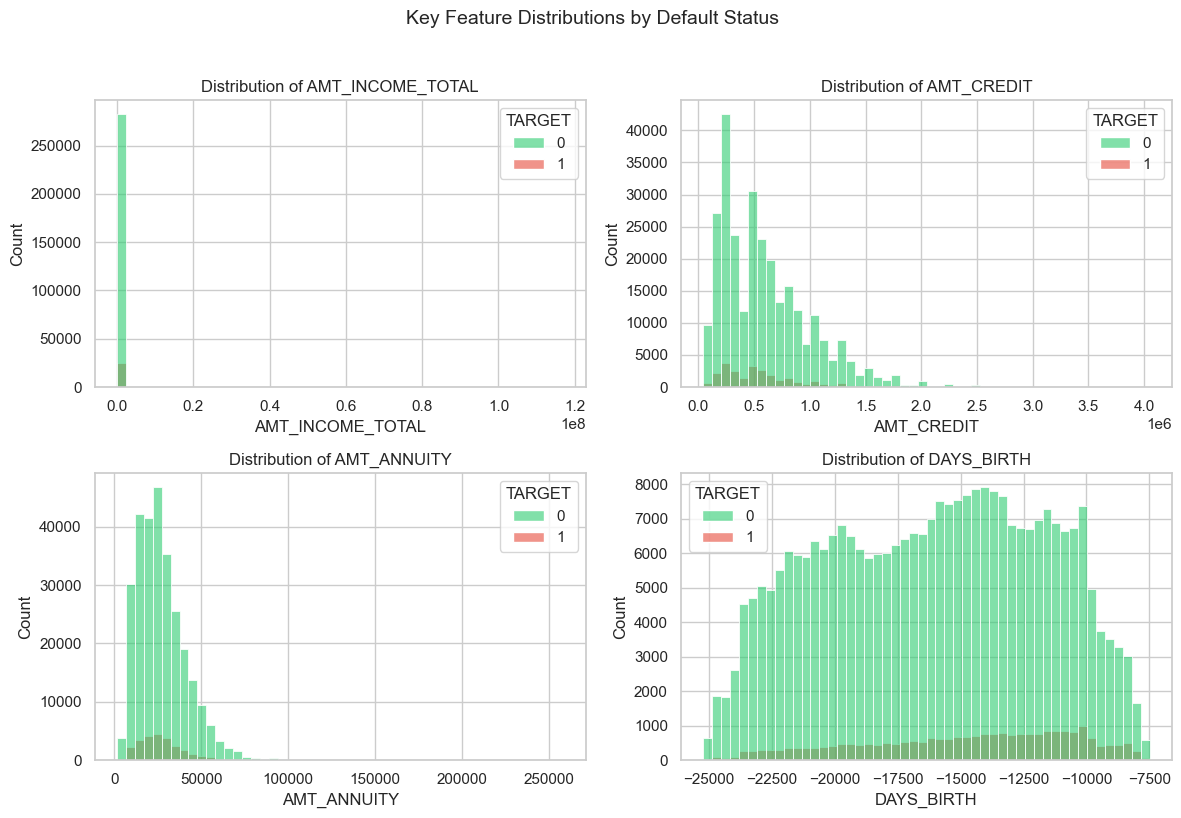

In [7]:
key_features = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'DAYS_BIRTH']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(key_features):
    sns.histplot(data=df, x=col, hue='TARGET', bins=50,
                 ax=axes[i], palette=['#2ecc71','#e74c3c'], alpha=0.6)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)

plt.suptitle('Key Feature Distributions by Default Status', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

C:\Users\thivy\AppData\Local\Temp\ipykernel_26424\71184439.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['AGE_YEARS'] = (-df['DAYS_BIRTH'] / 365).astype(int)


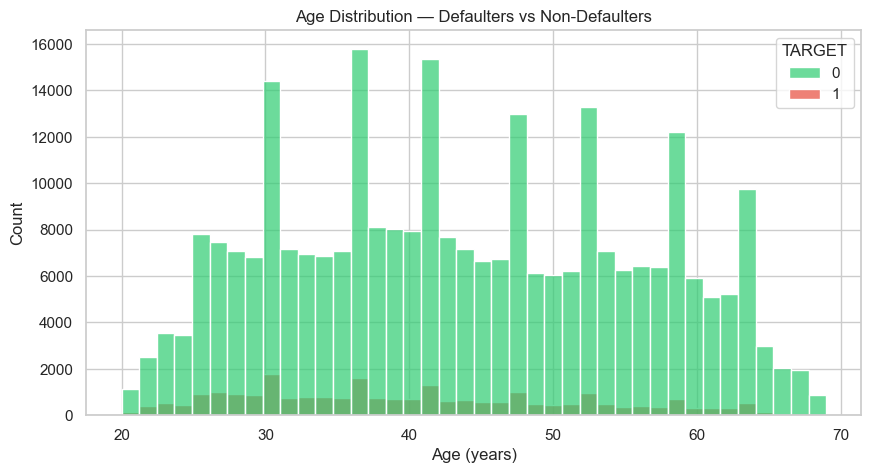

Average age of non-defaulters: 43.7 years
Average age of defaulters:     40.3 years


In [8]:
# DAYS_BIRTH is negative (days before application), convert to years
df['AGE_YEARS'] = (-df['DAYS_BIRTH'] / 365).astype(int)

plt.figure(figsize=(10,5))
sns.histplot(data=df, x='AGE_YEARS', hue='TARGET',
             bins=40, palette=['#2ecc71','#e74c3c'], alpha=0.7)
plt.title('Age Distribution — Defaulters vs Non-Defaulters')
plt.xlabel('Age (years)')
plt.ylabel('Count')
plt.show()

print(f"Average age of non-defaulters: {df[df['TARGET']==0]['AGE_YEARS'].mean():.1f} years")
print(f"Average age of defaulters:     {df[df['TARGET']==1]['AGE_YEARS'].mean():.1f} years")

C:\Users\thivy\AppData\Local\Temp\ipykernel_26424\758252289.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']
C:\Users\thivy\AppData\Local\Temp\ipykernel_26424\758252289.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='TARGET', y='CREDIT_INCOME_RATIO',


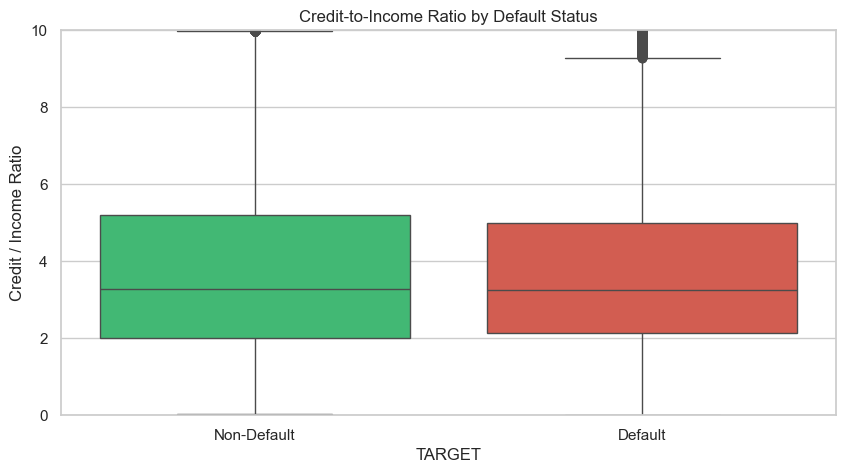

Avg ratio non-defaulters: 3.96x
Avg ratio defaulters:     3.89x


In [9]:
df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']

plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='TARGET', y='CREDIT_INCOME_RATIO',
            palette=['#2ecc71','#e74c3c'])
plt.title('Credit-to-Income Ratio by Default Status')
plt.xticks([0,1], ['Non-Default', 'Default'])
plt.ylabel('Credit / Income Ratio')
plt.ylim(0, 10)
plt.show()

print(f"Avg ratio non-defaulters: {df[df['TARGET']==0]['CREDIT_INCOME_RATIO'].mean():.2f}x")
print(f"Avg ratio defaulters:     {df[df['TARGET']==1]['CREDIT_INCOME_RATIO'].mean():.2f}x")

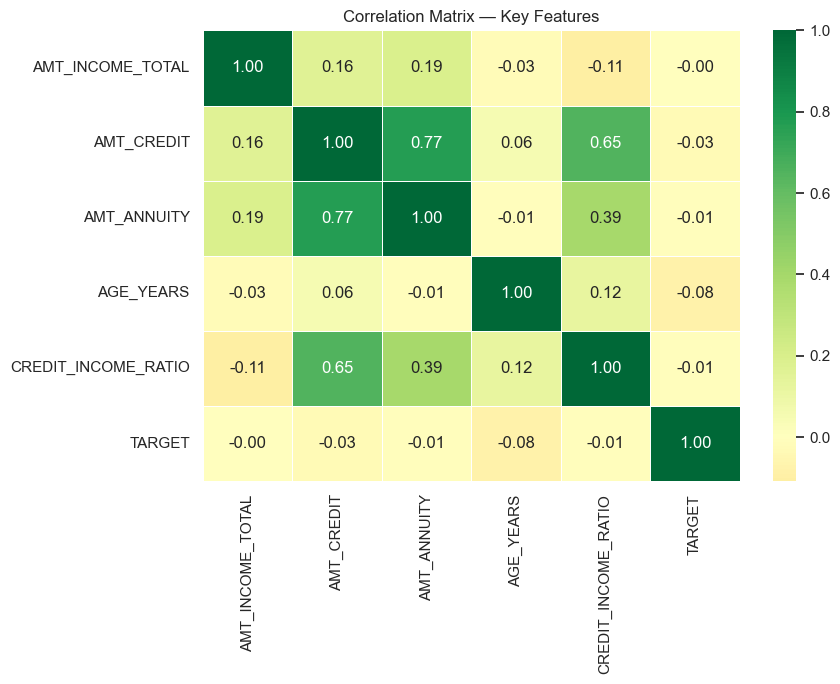

In [10]:
num_cols = ['AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY',
            'AGE_YEARS','CREDIT_INCOME_RATIO','TARGET']

plt.figure(figsize=(9,7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5)
plt.title('Correlation Matrix — Key Features')
plt.tight_layout()
plt.show()

In [11]:
print("=" * 50)
print("EDA SUMMARY — LOAN DEFAULT DATASET")
print("=" * 50)
print(f"Total applications : {len(df):,}")
print(f"Total features     : {df.shape[1]}")
print(f"Default rate       : {df['TARGET'].mean()*100:.1f}%")
print(f"Missing value cols : {(df.isnull().sum()>0).sum()}")
print(f"Avg applicant age  : {df['AGE_YEARS'].mean():.1f} years")
print(f"Avg loan amount    : RM {df['AMT_CREDIT'].mean():,.0f}")
print(f"Avg income         : RM {df['AMT_INCOME_TOTAL'].mean():,.0f}")
print("=" * 50)
print("Key insight: Dataset is heavily imbalanced!")
print("We will fix this with SMOTE in Phase 2.")

EDA SUMMARY — LOAN DEFAULT DATASET
Total applications : 307,511
Total features     : 124
Default rate       : 8.1%
Missing value cols : 67
Avg applicant age  : 43.4 years
Avg loan amount    : RM 599,026
Avg income         : RM 168,798
Key insight: Dataset is heavily imbalanced!
We will fix this with SMOTE in Phase 2.
